# Integrative Analysis of Breast Cancer Susceptibility Loci and Tumor Immune Programs Reveals Immune-Associated Candidate Genes in Triple-Negative Breast Cancer

---
## Notebook 10 - Systems-Level Prioritization of Immune-Associated Breast Cancer Susceptibility Genes

### Objective

This notebook constructs a bipartite interaction network to visualize statistically significant associations between prioritized breast cancer susceptibility genes and immune pathway activity within the TNBC cohort.

The network integrates the correlation analysis performed in the previous notebook by representing susceptibility genes and immune programs as distinct node classes connected by significant gene–pathway associations.

This systems-level representation highlights candidate genes that may act as molecular interfaces between inherited breast cancer susceptibility and the tumor immune microenvironment.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

### 1. Load Significant Gene–Immune Associations

Load the correlation statistics generated in the previous notebook.

Only statistically significant associations identified after global false discovery rate (FDR) correction are retained for network construction. This filtering ensures that the network highlights the most robust gene–immune relationships.

In [2]:
corr_df = pd.read_csv("../results/tables/gwas_immune_global_correlation_statistics.csv")

In [3]:
global_sig_pairs = corr_df[corr_df['Is_Significant_FDR_05'] == True].copy()

print(f"Isolated {len(global_sig_pairs)} globally significant interaction pairs.")

Isolated 26 globally significant interaction pairs.


### Significant Associations Identified

The filtered dataset contains gene–pathway associations that remain significant following Benjamini–Hochberg FDR correction.

These significant interactions form the edges of the bipartite network.

### 2. Construct the Bipartite Network

Create a bipartite graph consisting of two biologically distinct node classes:

- **Prioritized susceptibility genes**
- **Immune Hallmark pathways**

An edge is added whenever a statistically significant correlation exists between a gene and an immune program.

In [4]:
G = nx.Graph()

target_genes = global_sig_pairs['Gene'].unique().tolist()
pathways = global_sig_pairs['Pathway'].unique().tolist()

In [5]:
G.add_nodes_from(target_genes, bipartite=0)
G.add_nodes_from(pathways, bipartite=1)

### 3. Encode Biological Relationships

Each network edge stores the corresponding Spearman correlation coefficient.

For visualization:

- **Red edges** indicate positive associations.
- **Blue edges** indicate negative associations.
- Edge width is proportional to the magnitude of the correlation coefficient, allowing stronger associations to appear more prominent.

In [6]:
edge_list = []
edge_colors = []
edge_widths = []


for _, row in global_sig_pairs.iterrows():
    gene = row['Gene']
    pw = row['Pathway']
    rho = row['Spearman_rho']
    
    G.add_edge(gene, pw, weight=rho)
    edge_list.append((gene, pw))
    
    if rho > 0:
        edge_colors.append('#DC2626')  
    else:
        edge_colors.append('#2563EB')  
        
    edge_widths.append(abs(rho) * 7.5)

### 4. Visualize the Multi-Scale Interaction Network

Generate a bipartite network illustrating statistically significant interactions between susceptibility genes and immune pathways.

The visualization enables rapid identification of genes associated with multiple immune programs and summarizes the integrated relationship between inherited genetic susceptibility and tumor immune activity.

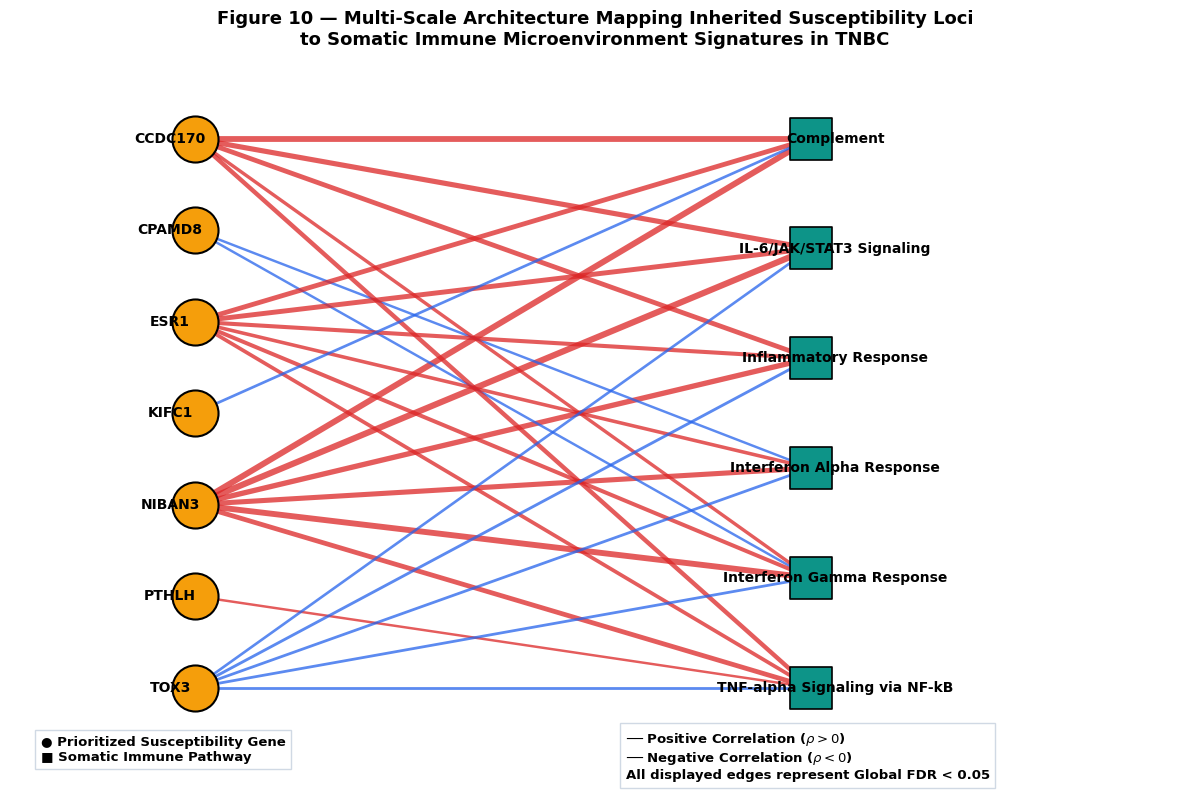

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

pos = {}

for idx, gene in enumerate(sorted(target_genes)):
    pos[gene] = np.array([-1.0, np.linspace(1.5, -1.5, len(target_genes))[idx]])

for idx, pw in enumerate(sorted(pathways)):
    pos[pw] = np.array([1.0, np.linspace(1.5, -1.5, len(pathways))[idx]])

label_pos = {}
for node, coords in pos.items():
    if node in target_genes:
        label_pos[node] = (coords[0] - 0.08, coords[1])   
    else:
        label_pos[node] = (coords[0] + 0.08, coords[1])   

nx.draw_networkx_nodes(
    G, pos,
    nodelist=target_genes,
    node_color='#F59E0B',
    node_size=1100,
    edgecolors='black',
    linewidths=1.5,
    ax=ax
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=pathways,
    node_color='#0D9488',
    node_size=900,
    node_shape='s',
    edgecolors='black',
    linewidths=1.2,
    ax=ax
)

for i, edge in enumerate(edge_list):
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[edge],
        edge_color=[edge_colors[i]],
        width=[edge_widths[i]],
        style='solid',
        alpha=0.75,
        ax=ax
    )

nx.draw_networkx_labels(
    G, label_pos, 
    font_size=10, 
    font_weight='bold', 
    horizontalalignment='center',
    ax=ax
)

ax.set_xlim(-1.6, 2.2)
ax.set_ylim(-1.9, 1.9)
ax.axis('off')

ax.set_title('Figure 10 — Multi-Scale Architecture Mapping Inherited Susceptibility Loci\nto Somatic Immune Microenvironment Signatures in TNBC', 
             fontsize=13, fontweight='bold', pad=15)


ax.text(-1.5, -1.9, "● Prioritized Susceptibility Gene\n■ Somatic Immune Pathway", 
        fontsize=9.5, fontweight='bold', bbox=dict(facecolor='white', alpha=0.9, edgecolor='#CBD5E1'))

ax.text(0.4, -2.0, r"── Positive Correlation ($\rho > 0$)" + "\n" + r"── Negative Correlation ($\rho < 0$)" + "\n" + "All displayed edges represent Global FDR < 0.05", 
        fontsize=9.5, fontweight='bold', bbox=dict(facecolor='white', alpha=0.9, edgecolor='#CBD5E1'))

plt.tight_layout()
plt.savefig('../results/figures/multi_gene_immune_bipartite_network.png', dpi=300, bbox_inches='tight')

### Interpretation of the Bipartite Risk–Immune Network

The bipartite network summarizes statistically significant associations between prioritized breast cancer susceptibility genes and immune pathway activity within the TNBC cohort.

Several genes emerge as highly connected nodes. NIBAN3 and ESR1 each exhibit significant positive associations with all six immune Hallmark pathways, indicating broad coordination with inflammatory, interferon, complement, and cytokine signaling programs. Similarly, CCDC170 displays positive connections with five immune pathways, suggesting a substantial role in the immune transcriptional landscape of TNBC.

In contrast, TOX3 forms predominantly negative connections with multiple immune pathways, indicating that higher TOX3 expression is associated with reduced immune pathway activity. Additional negative associations involving CPAMD8 and KIFC1 suggest that some susceptibility genes may participate in distinct transcriptional programs linked to comparatively lower immune activation.

The network architecture also illustrates that immune pathways are influenced by multiple susceptibility-associated genes rather than by isolated gene–pathway relationships. Conversely, several genes connect to multiple immune programs, highlighting potential regulatory hubs within the integrated germline–tumor immune landscape.

Overall, this systems-level visualization identifies NIBAN3, ESR1, CCDC170, and TOX3 as the principal immune-associated susceptibility genes emerging from this integrative analysis and provides a concise summary of the molecular interactions linking inherited breast cancer risk with immune phenotypes in TNBC.

---

### 5. Integrating Differential Expression with Immune Associations

The bipartite network identifies susceptibility genes whose expression is significantly associated with immune pathway activity within the TNBC cohort. To further characterize these candidates, the direction of differential expression identified by DESeq2 was integrated with their immune correlation profiles.

These two analyses provide complementary biological perspectives. Differential expression analysis identifies genes that distinguish TNBC from other breast cancer subtypes, whereas correlation analysis evaluates how variation in gene expression relates to immune pathway activity among TNBC tumors. Consequently, a gene may be downregulated overall in TNBC while still exhibiting a positive association with immune signaling within the TNBC cohort.

Integrating these analytical layers enables prioritization of candidate genes according to both their transcriptional dysregulation and their relationship with the tumor immune microenvironment.


#### Integrated Biological Interpretation

| Gene        | DESeq2 Status   | Immune Association    | Biological Interpretation                                                                                                                                                                               |
| ----------- | --------------- | --------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **NIBAN3**  | ↑ Upregulated   | Positive (6 pathways) | Elevated in TNBC and consistently associated with increased immune pathway activity, making it a strong candidate linking tumor biology with immune regulation.                                         |
| **CPAMD8**  | ↑ Upregulated   | Negative (2 pathways) | Overexpressed in TNBC but associated with reduced interferon pathway activity, suggesting a potential relationship with immune suppression or an alternative tumor transcriptional program.             |
| **KIFC1**   | ↑ Upregulated   | Negative (1 pathway)  | Upregulated in TNBC but negatively associated with Complement signaling, indicating that increased expression may not correspond to enhanced immune activation.                                         |
| **ESR1**    | ↓ Downregulated | Positive (6 pathways) | Although reduced overall in TNBC, relatively higher expression among TNBC tumors is associated with stronger immune pathway activity, suggesting a potential immune-supportive role within the subtype. |
| **CCDC170** | ↓ Downregulated | Positive (5 pathways) | Downregulated in TNBC but positively associated with multiple immune pathways, indicating that residual expression tracks with a more immune-active tumor microenvironment.                             |
| **PTHLH**   | ↓ Downregulated | Positive (1 pathway)  | Downregulated overall yet positively associated with TNF-α signaling, suggesting a more pathway-specific relationship with immune activity.                                                             |
| **TOX3**    | ↓ Downregulated | Negative (5 pathways) | Reduced in TNBC and negatively associated with several immune pathways, indicating that higher TOX3 expression within TNBC corresponds to lower immune pathway activity.                                |


#### Biological Patterns Emerging from the Integrated Analysis

The integrated analysis identifies four distinct biological patterns among the prioritized susceptibility genes:

#### 1. Upregulated genes with positive immune associations

**NIBAN3**

These genes are transcriptionally activated in TNBC and are associated with increased immune pathway activity. Such candidates may represent important interfaces between tumor-specific transcriptional alterations and immune regulation.


#### 2. Upregulated genes with negative immune associations

**CPAMD8, KIFC1**

These genes are overexpressed in TNBC but exhibit negative correlations with one or more immune pathways. This pattern suggests that elevated expression does not necessarily correspond to enhanced immune activation and may instead reflect transcriptional programs associated with reduced immune signaling.


#### 3. Downregulated genes with positive immune associations

**ESR1, CCDC170, PTHLH**

Although these genes are expressed at lower levels in TNBC relative to other breast cancer subtypes, TNBC tumors retaining comparatively higher expression demonstrate increased immune pathway activity. This pattern suggests that these genes may be associated with more immune-responsive tumor states despite their overall reduction in TNBC.


#### 4. Downregulated genes with negative immune associations

**TOX3**

TOX3 exhibits both reduced expression in TNBC and negative associations with multiple immune pathways. This distinctive pattern suggests that variation in TOX3 expression may reflect a transcriptional program linked to lower immune activity within TNBC, although further experimental investigation is required to clarify its biological role.


#### Overall Interpretation

Integrating differential expression with immune correlation analysis reveals that prioritized susceptibility genes are not uniformly associated with the tumor immune microenvironment. Instead, they exhibit distinct expression–immune relationship patterns that likely reflect diverse biological roles in TNBC.

Among the identified candidates, **NIBAN3** emerges as the strongest immune-associated susceptibility gene, combining significant upregulation in TNBC with coordinated positive associations across all evaluated immune pathways. **ESR1** and **CCDC170** demonstrate an alternative pattern in which reduced expression relative to other breast cancer subtypes is accompanied by positive immune associations within TNBC, suggesting that preserved expression of these genes may characterize more immune-active tumors. Conversely, **TOX3**, **CPAMD8**, and **KIFC1** exhibit negative immune associations, highlighting candidates that may be linked to comparatively immune-poor transcriptional states.

Collectively, these findings illustrate how integrating germline susceptibility, tumor transcriptomics, and immune pathway activity provides a more comprehensive view of TNBC biology than any single analytical approach alone. This multi-layer framework refines a broad list of susceptibility genes into a smaller set of biologically prioritized candidates for future mechanistic and experimental investigation.